In [46]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, filters, morphology, measure
import seaborn as sns
import pandas as pd

from sklearn import decomposition

In [3]:
path = "/home/kkristjansson/DTU/spring2026/02515_Image_Analysis/imageAnalysisGithub/exercises/ex1b-PCA/data/"

In [1]:
file = "irisdata.txt"

In [19]:
#Lx-1b.1: Use numpy to read txt file

iris_data = np.loadtxt(path + file, comments="%")
print(iris_data.shape
      )

#Lx-1b.2 Create a data matrix from a txt file 
X = (iris_data[0:50,0:4])


(150, 5)


In [20]:
#Lx-1b.3: Organize measured data into a data matrix

n_feat = X.shape[1]
n_obs = X.shape[0]

In [26]:
#Lx-1b-4: Compute the variance of a set of measurements
sep_l = X[:,0]
sep_w = X[:,1]
pet_l = X[:,2]
pet_w = X[:,3]

var_sep_l = sep_l.var(ddof=1)



In [ ]:
#Lx-1b-5: Compute the covariance between two sets of measurements
cov_l = sep_l.dot(pet_l)/(n_obs-1)
cov_w = sep_w.dot(pet_w)/(n_obs-1)

print(f"Sepal length, petal length covariance: {cov_l:2f}. ")
print(f"Sepal length, sepal width covariance: {cov_w:2f}. ")

Sepal length, petal length covariance: 7.484490. 
Sepal length, sepal width covariance: 0.869796. 


<Figure size 640x480 with 0 Axes>

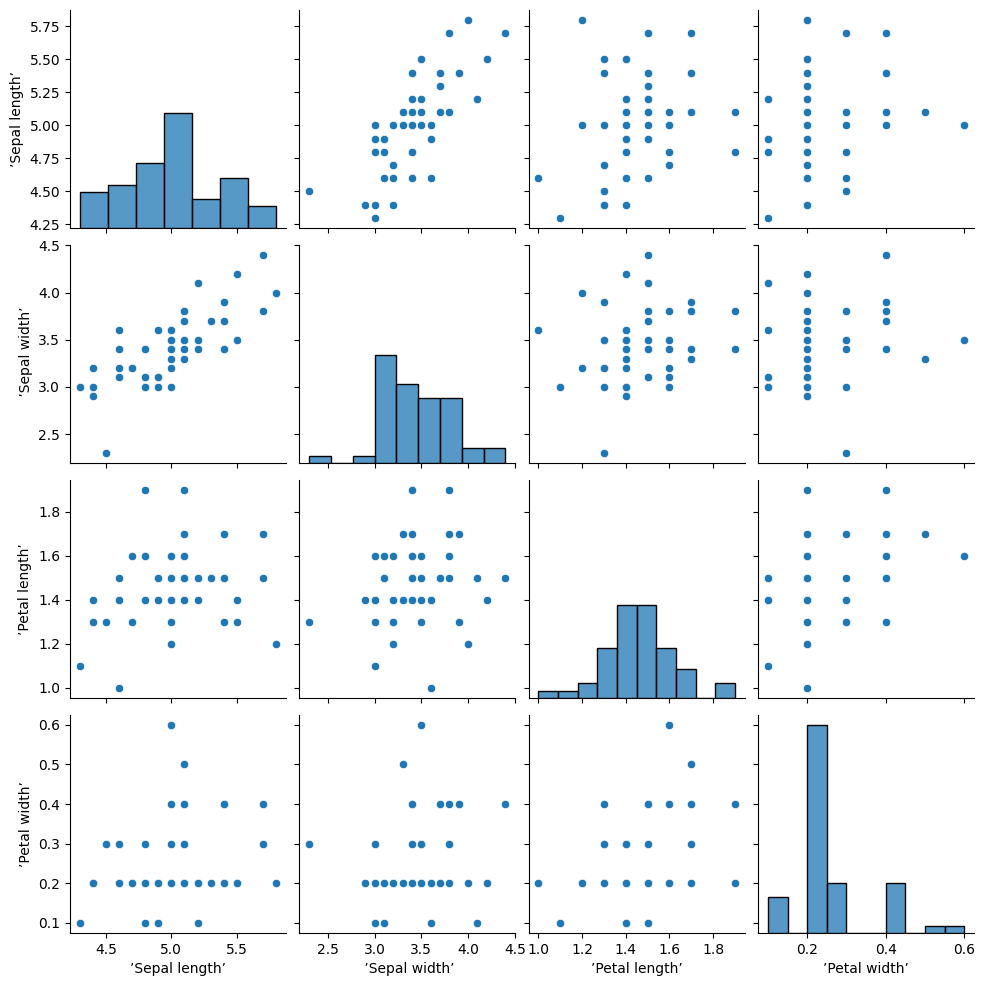

In [33]:
#Lx-1b-6: Use the function pairplot from the seaborn package to visualize the variance between multiple sets of measurements
plt.figure() # Added this to make sure that the figure appear
# Transform the data into a Pandas dataframe
d = pd.DataFrame(X, columns=["’Sepal length’"," ’Sepal width’",
                             
"’Petal length’", "’Petal width’"])
sns.pairplot(d)
plt.show()

In [40]:
#Lx-1b-7:  Compute the covariance matrix from multiple sets of measurements using matrix muplication

X = np.array([sep_l, sep_w, pet_l, pet_w])

X_centred = X - X.mean(axis=1, keepdims=True)

cov_matrix = X_centred.dot(X_centred.T) / (n_obs-1)

print(f"Covariance matrix shape: {cov_matrix.shape}")
print(f"Covariance matrix:\n{cov_matrix}")

Covariance matrix shape: (4, 4)
Covariance matrix:
[[0.12424898 0.09921633 0.0163551  0.01033061]
 [0.09921633 0.1436898  0.01169796 0.00929796]
 [0.0163551  0.01169796 0.03015918 0.00606939]
 [0.01033061 0.00929796 0.00606939 0.01110612]]


In [41]:
#Lx-1b-8: Compute the covariance matrix from multiple sets of measurements using the NumPy cov function
mn = np.mean(X, axis = 0)
data = X - mn

c_x = (data.T @ data)/(n_obs - 1)
c_w_np = np.cov(data.T)

np.allclose(c_x,c_w_np) #check if the matrics are equal

False

In [42]:
#Lx-1b-9: Compute the principal components using eigenvector analysis (numpy function eig)
values, vectors = np.linalg.eig(c_x) # Here c_x is your covariance matrix.



/home/kkristjansson/.local/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/kkristjansson/.local/lib/python3.10/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


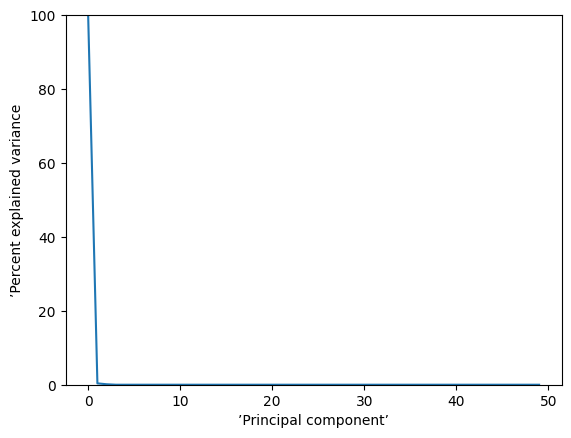

In [44]:
#Lx-1b-10: Visualize how much of the total variation each principal component explains


v_norm = values / values.sum() * 100
plt.plot(v_norm)
plt.xlabel("’Principal component’")
plt.ylabel("’Percent explained variance")
plt.ylim([0, 100])

plt.show()


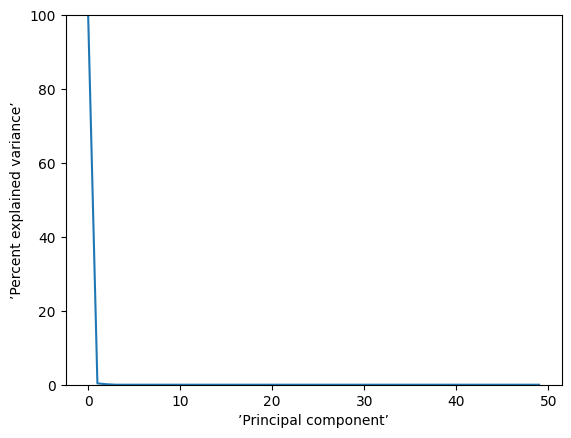

In [45]:
#Lx-1b-11: Project original measurements into principal component space
pc_proj = vectors.T.dot(data.T)
v_norm = values / values.sum() * 100
plt.plot(v_norm)
plt.xlabel("’Principal component’")
plt.ylabel("’Percent explained variance’")
plt.ylim([0, 100])

plt.show()



In [39]:
#Lx-1b-12: Use the function pairplot to visualize the covariance structure after projecting to principal component space

In [48]:
#Lx-1b-13: Compute the PCA using the PCA function from the sci-kit learn decomposition package

pca = decomposition.PCA()
pca.fit(X)
values_pca = pca.explained_variance_
exp_var_ratio = pca.explained_variance_ratio_
vectors_pca = pca.components_

data_transform = pca.transform(X)